In [130]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:

# Pipeline:
#  Define a neural net
#  Create a dataset to train on. Standard classifier example, or maybe XOR (or both)
#  Create a function script which enables either Cross-entropy or Direction loss function [ESSENTIAL]
#  Training model on the dataset on set of training points (very few -> 100% accuracy) [ESSENTIAL]

## Standard libraries
import numpy as np
import pickle
import yaml

import matplotlib.pyplot as plt

## Progress bar
from tqdm.auto import tqdm

#ML Libraries
import jax
import optax

import os

import torch.utils.data as data

# Custom Libraries
from counterfactual_alignment.custom_models   import SimpleClassifier, SimpleClassifier_v2, MLP, CNN,  GSPaper, GSPaperNew, GSPaper2, GSPaper3, BagOfWordsClassifier, BagOfWordsClassifierSimple, BagOfWordsClassifierSingle
from counterfactual_alignment.custom_datasets import customDataset, genCustomDataset
from counterfactual_alignment.custom_datasets import datasets as custom_datasets
from counterfactual_alignment.loss_functions import loss_functions
from counterfactual_alignment.knowledge_functions import knowledge_functions
from counterfactual_alignment.knowledge_functions import counterfactual_vector_paths, counterfactual_feasible_vector_paths, counterfactual_breadcrumbs
import  counterfactual_alignment.utilities  as ut

import torch


rng:  RandomState(MT19937)  SIZE:  3


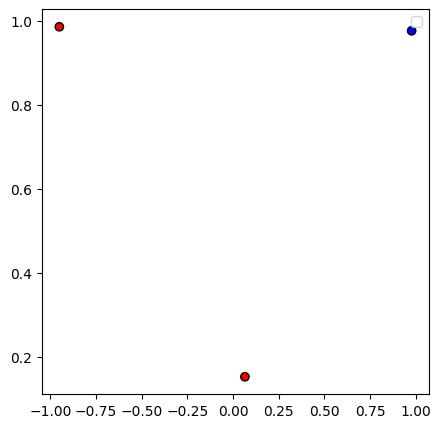

In [132]:

# Get the directory where THIS script is located
"""
# project_dir = os.path.dirname(os.path.abspath(__file__))

with open(os.path.join(project_dir,'config.yaml'),'r') as file:
    config = yaml.unsafe_load(file)
"""
with open('config.yaml','r') as file:
    config = yaml.unsafe_load(file)
"""
Generate DATASET
"""
data_name = config['data_params']['dataset']

train = genCustomDataset(custom_datasets[data_name],config['data_params']['train_size'],None,
                         train=True,
                         visualise=config['visualisation']['visualise'],
                         seed=config['hyperparams']['seed'],
                         n_vec = config['data_params']['n_vec'])


rng:  RandomState(MT19937)  SIZE:  200


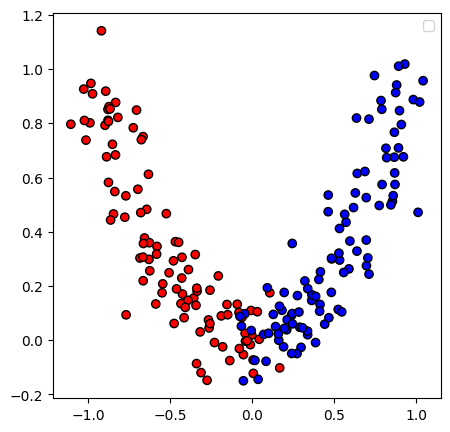

In [133]:

validation = genCustomDataset(custom_datasets[data_name],config['data_params']['validation_size'],None,
                         train=False,
                         visualise=config['visualisation']['visualise'],
                         seed=config['hyperparams']['seed'],
                         n_vec = config['data_params']['n_vec'])

In [134]:
# K = counterfactual_feasible_vector_paths(train.X,train.Y,train.data.optimum_classifier,n_samples=2)
start_idx = list(train.X[:,0]).index(min(train.X[:,0]))
end_idx = list(train.X[:,0]).index(max(train.X[:,0]))

breadcrumbs = counterfactual_breadcrumbs(train.X[start_idx],train.X[end_idx],classifier = train.data.optimum_classifier,n_breadcrumbs=5)

X:  [-0.62917638 -0.30802417  0.01312804  0.33428025  0.65543245]
Y:  [3.95862913e-01 9.48788887e-02 1.72345406e-04 1.11743283e-01
 4.29591703e-01]


In [135]:
breadcrumbs

{'origins': array([[-6.29176377e-01,  3.95862913e-01],
        [-3.08024169e-01,  9.48788887e-02],
        [ 1.31280389e-02,  1.72345406e-04],
        [ 3.34280247e-01,  1.11743283e-01],
        [ 6.55432455e-01,  4.29591703e-01]]),
 'vectors': array([[ 0.72964622, -0.68382483],
        [ 0.95916313, -0.28285349],
        [ 0.94461919,  0.32816853],
        [ 0.7107532 ,  0.70344147],
        [ 0.50630628,  0.86235373]]),
 'labels': array([0, 0, 1, 1, 1])}

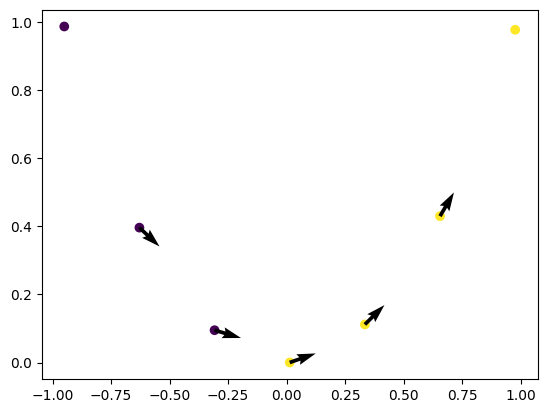

In [136]:


x = breadcrumbs['origins'][:,0]
y = breadcrumbs['origins'][:,1]
u = breadcrumbs['vectors'][:,0]
v = breadcrumbs['vectors'][:,1]

x_start,y_start = train.X[start_idx]
x_end,y_end = train.X[end_idx]
plt.scatter([x_start,x_end],[y_start,y_end],c=train.data.optimum_classifier([train.X[start_idx],train.X[end_idx]]))
plt.scatter(x,y,c = train.data.optimum_classifier(breadcrumbs['origins']))
plt.quiver(x,y,u,v)


In [137]:
output_path = "outputs/" + data_name + "/"
os.makedirs(output_path, exist_ok=True)

"""
Initialise Parameters
"""

n_models = 6
n_epochs = config['hyperparams']['epochs']
overwrite = True

n_vectors = len(train.X[0])

rng = jax.random.PRNGKey(42)

rng, inp_rng, init_rng, dropout_rng, embedding_rng = jax.random.split(rng, 5)


In [138]:
"""
Model Parameters
"""
loss_name = config['hyperparams']['loss_function'] # "direction", 'cross_entropy_batch', 'cross_entropy_l2', 'direction', 'direction_interactive' & more - see loss functions
learning_rate = config['hyperparams']['learning_rate']
batch_size = config['hyperparams']['batch_size']


warmup_steps = 100
peak_lr = 1.0
final_lr = 1e-3

schedule = optax.join_schedules(
    schedules=[
        optax.linear_schedule(init_value=0.0, end_value=peak_lr, transition_steps=warmup_steps),
        optax.exponential_decay(init_value=peak_lr, transition_steps=100, decay_rate=0.9)
    ],
    boundaries=[warmup_steps]
)

# optimiser = optax.adam(schedule)

optimiser = optax.chain(
    optax.clip_by_global_norm(1.0),  # Clip gradients
    optax.adam(schedule)
)


# Define a learning rate schedule (e.g., exponential decay)
learning_rate_schedule = optax.exponential_decay(
    init_value=1,  # Starting learning rate
    transition_steps=50,  
    decay_rate=0.9,  # Decay factor
    transition_begin=10,  # When to start the decay
    staircase=False  # Set to True for a staircase effect
)

sgd_opt = optax.sgd(learning_rate=0.01,momentum=0.8 )
adam_opt = optax.adam(learning_rate=learning_rate)
scheduled_adadelta = optax.adadelta(learning_rate=learning_rate_schedule, weight_decay=0.05)
adamw = optax.adamw(
    learning_rate=1e-3,
    b1=0.9,
    b2=0.999,
    eps=1e-8,
    weight_decay=0.0
)
adadelta = optax.adadelta(
    learning_rate=1,    # default
    rho=0.95,              # decay rate
    eps=1e-6
)
scheduled_adadelta = optax.adadelta(learning_rate=learning_rate_schedule, weight_decay=0.05)

# optimiser = adamw
# optimiser = scheduled_adadelta
# optimiser = adadelta
optimiser = adam_opt

optim_name = [oname for oname in [name for name, value in locals().items() if value is optimiser] if oname != 'optimiser'][0]


In [139]:


ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


In [140]:


for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":train.X,
            "Y":train.Y,
            "K":None
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + 'FULL' + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 20%|██        | 2/10 [00:00<00:01,  6.25it/s]

Train Loss: 0.6653594970703125, Train Accuracy: 100.0
Validation Loss: 0.6732003092765808, Validation Accuracy: 84.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3
Train Loss: 0.6235079169273376, Train Accuracy: 100.0
Validation Loss: 0.6444369554519653, Validation Accuracy: 89.0


 40%|████      | 4/10 [00:00<00:00,  6.55it/s]

Train Loss: 0.5853051543235779, Train Accuracy: 100.0
Validation Loss: 0.6181816458702087, Validation Accuracy: 88.5
Train Loss: 0.5498548746109009, Train Accuracy: 100.0
Validation Loss: 0.594173014163971, Validation Accuracy: 87.5


 60%|██████    | 6/10 [00:00<00:00,  6.43it/s]

Train Loss: 0.5162330269813538, Train Accuracy: 100.0
Validation Loss: 0.5717259049415588, Validation Accuracy: 87.0
Train Loss: 0.4842507839202881, Train Accuracy: 100.0
Validation Loss: 0.5508543848991394, Validation Accuracy: 85.99999237060547
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


 80%|████████  | 8/10 [00:01<00:00,  6.30it/s]

Train Loss: 0.45369312167167664, Train Accuracy: 100.0
Validation Loss: 0.531470000743866, Validation Accuracy: 85.99999237060547
Train Loss: 0.42475563287734985, Train Accuracy: 100.0
Validation Loss: 0.5135861039161682, Validation Accuracy: 85.0


100%|██████████| 10/10 [00:01<00:00,  6.44it/s]

Train Loss: 0.39708563685417175, Train Accuracy: 100.0
Validation Loss: 0.496902197599411, Validation Accuracy: 84.5
Train Loss: 0.37030667066574097, Train Accuracy: 100.0
Validation Loss: 0.48150762915611267, Validation Accuracy: 83.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


limiting to random subsample of X


In [141]:


ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


In [142]:

randints = np.random.choice(len(train.X),2)

X = train.X[randints]
Y = train.Y[randints]

In [143]:

for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + "SUBSAMPLE" + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 20%|██        | 2/10 [00:00<00:01,  6.59it/s]

Train Loss: 0.6908954381942749, Train Accuracy: 33.333335876464844
Validation Loss: 0.6865499019622803, Validation Accuracy: 51.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3
Train Loss: 0.6722618937492371, Train Accuracy: 33.333335876464844
Validation Loss: 0.6703996062278748, Validation Accuracy: 53.499996185302734


 40%|████      | 4/10 [00:00<00:00,  6.54it/s]

Train Loss: 0.6529524326324463, Train Accuracy: 33.333335876464844
Validation Loss: 0.6561034321784973, Validation Accuracy: 67.5
Train Loss: 0.6333742141723633, Train Accuracy: 33.333335876464844
Validation Loss: 0.6433244943618774, Validation Accuracy: 78.5


 60%|██████    | 6/10 [00:00<00:00,  6.68it/s]

Train Loss: 0.6139058470726013, Train Accuracy: 66.66667175292969
Validation Loss: 0.631363034248352, Validation Accuracy: 82.5
Train Loss: 0.5947048664093018, Train Accuracy: 66.66667175292969
Validation Loss: 0.6201345920562744, Validation Accuracy: 87.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


 80%|████████  | 8/10 [00:01<00:00,  6.85it/s]

Train Loss: 0.5757256150245667, Train Accuracy: 66.66667175292969
Validation Loss: 0.6096220016479492, Validation Accuracy: 90.5
Train Loss: 0.5568007826805115, Train Accuracy: 100.0
Validation Loss: 0.5996251106262207, Validation Accuracy: 89.0


100%|██████████| 10/10 [00:01<00:00,  6.66it/s]

Train Loss: 0.5380005240440369, Train Accuracy: 100.0
Validation Loss: 0.5900039672851562, Validation Accuracy: 87.5
Train Loss: 0.5191308259963989, Train Accuracy: 100.0
Validation Loss: 0.5805537104606628, Validation Accuracy: 85.49999237060547
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


### Now adding K

In [144]:
loss_name ='combined_loss'

ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


In [145]:

for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + 'SUBSAMPLEwithK' + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 10%|█         | 1/10 [00:00<00:02,  3.78it/s]

Train Loss: 0.6817436218261719, Train Accuracy: 33.333335876464844
Validation Loss: 0.6814360618591309, Validation Accuracy: 52.499996185302734
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


 20%|██        | 2/10 [00:00<00:02,  3.84it/s]

Train Loss: 0.6531524658203125, Train Accuracy: 66.66667175292969
Validation Loss: 0.6595428586006165, Validation Accuracy: 83.5


 30%|███       | 3/10 [00:00<00:01,  3.87it/s]

...

Train Loss: 0.4943331182003021, Train Accuracy: 100.0
Validation Loss: 0.5649870038032532, Validation Accuracy: 91.5


 90%|█████████ | 9/10 [00:02<00:00,  3.90it/s]

Train Loss: 0.47055673599243164, Train Accuracy: 100.0
Validation Loss: 0.5532320141792297, Validation Accuracy: 88.5


100%|██████████| 10/10 [00:02<00:00,  3.87it/s]

Train Loss: 0.44708359241485596, Train Accuracy: 100.0
Validation Loss: 0.542171835899353, Validation Accuracy: 87.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


### NOW just with X from K

In [146]:
loss_name ='cross_entropy'

ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


In [147]:
X = np.concatenate((X,breadcrumbs['origins']))
Y = np.concatenate((Y,breadcrumbs['labels']))


for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + "SUBSAMPLEwithX" + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 20%|██        | 2/10 [00:00<00:01,  5.58it/s]

Train Loss: 0.6747066378593445, Train Accuracy: 66.66667175292969
Validation Loss: 0.666001558303833, Validation Accuracy: 94.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3
Train Loss: 0.6414563655853271, Train Accuracy: 66.66667175292969
Validation Loss: 0.6305109262466431, Validation Accuracy: 93.0


 40%|████      | 4/10 [00:00<00:00,  6.45it/s]

Train Loss: 0.6104416251182556, Train Accuracy: 66.66667175292969
Validation Loss: 0.5982265472412109, Validation Accuracy: 91.99999237060547
Train Loss: 0.5823225975036621, Train Accuracy: 66.66667175292969
Validation Loss: 0.5685110092163086, Validation Accuracy: 92.49999237060547


 50%|█████     | 5/10 [00:00<00:00,  5.81it/s]

...

Validation Loss: 0.5148662328720093, Validation Accuracy: 91.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3
Train Loss: 0.5101596117019653, Train Accuracy: 66.66667175292969
Validation Loss: 0.4900912344455719, Validation Accuracy: 91.5


 80%|████████  | 8/10 [00:01<00:00,  6.07it/s]

Train Loss: 0.48919588327407837, Train Accuracy: 66.66667175292969
Validation Loss: 0.4664055407047272, Validation Accuracy: 91.5
Train Loss: 0.4693925082683563, Train Accuracy: 66.66667175292969


100%|██████████| 10/10 [00:01<00:00,  5.84it/s]

Validation Loss: 0.44351959228515625, Validation Accuracy: 91.5
Train Loss: 0.45025551319122314, Train Accuracy: 66.66667175292969
Validation Loss: 0.4213413894176483, Validation Accuracy: 91.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_cross_entropy_alpha_1000.95__SIZE3


### And finally both

In [148]:
loss_name ='combined_loss'

ensemble = {
            # 'models':[BagOfWordsClassifier(20000,50)]*n_models,
            'models':[SimpleClassifier_v2(*config['hyperparams']['model_io'])]*n_models,
            'rngs':jax.random.split(rng,n_models),
            'init_rngs':jax.random.split(init_rng,n_models),
            'train_states':[],
            'outputs':{
              'params':[None]*n_models,
              'results':{
                'Train':{'losses':[],'accuracy':[]},
                'Validation':{'losses':[],'accuracy':[]}, 
                }
                }}


# model = GSPaper3(8,1)
model_name = type(ensemble['models'][0]).__name__
output_name = f"MODEL_ENSEMBLE_{n_models}_{model_name}__OPTIM_{optim_name}__LR_{learning_rate}__BATCHSIZE_{config['hyperparams']['batch_size']}__DATA_{data_name}_filtered__LOSS_{loss_name}_alpha_{config['hyperparams']['loss_mix']}__SIZE{config['data_params']['train_size']}"
print("Loading and saving to : ", output_name)

for i in range(n_models):
    # trained_state, model = create_train_state(ensemble['models'][i],ensemble['init_rngs'][i],optimiser,batch_size=batch_size,vector_length=n_vectors)
    trained_state, model = ut.create_train_state(ensemble['models'][i],optimiser,vector_length=n_vectors,key = ensemble['init_rngs'][i])
    ensemble['train_states'].append(trained_state)
    ensemble['models'][i] = model
    ensemble['outputs']['params'][i] = trained_state.params


if not overwrite:
    try:

        with open(output_path + output_name+'.pkl', 'rb') as file: ## remove this line to load model
            res = pickle.load(file)

        ensemble['outputs']['params'] = res['params']
        
        for i,trainstate in enumerate(ensemble['train_states']):
            ensemble['train_states'][i] = ensemble['train_states'][i].replace(params = res['params'][i])
        
        ensemble['outputs']['results'] = res['results']

        print(f'Model loaded from {output_name}')
        
    except:
        pass

# Filter out any case where counterfactual is the same as the original
plot_states = []
last_val_acc = 0

Loading and saving to :  MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


In [149]:
X = np.concatenate((X,breadcrumbs['origins']))
Y = np.concatenate((Y,breadcrumbs['labels']))


for epoch in tqdm(range(n_epochs)):
            
    for m in range(n_models):
        model = ensemble['models'][m]
        trained_state = ensemble['train_states'][m]
        rng = ensemble['rngs'][m]
        batch = {
            "X":X,
            "Y":Y,
            "K":breadcrumbs
        }
        trained_state, train_metrics = ut.train_one_epoch(trained_state, batch, model, loss_functions[loss_name],rng)
            
        
        ensemble['outputs']['params'][m]=trained_state.params
        ensemble['train_states'][m] = trained_state
        if m == 0:
            plot_states.append(trained_state)
        
        

                                                    #  model, loss_functions['cross_entropy_l2'])
                                            
        # trained_state,metrics = train_one_epoch(trained_state, train_data_loader)
        # print(f"Epoch Loss: {train_metrics['loss']}, Epoch Accuracy: {train_metrics['accuracy'] * 100}")
    
    models = ensemble['models']
    ensemble_params = ensemble['outputs']['params']
    
    train_metrics = ut.generate_results_ensemble(train.X,train.Y,models,ensemble_params,name="Train")
    val_metrics = ut.generate_results_ensemble(validation.X,validation.Y,models,ensemble_params,name="Validation")
    


    ensemble['outputs']['results']['Train']['losses'].append(train_metrics['loss'])
    ensemble['outputs']['results']['Train']['accuracy'].append(train_metrics['accuracy'])
    
    ensemble['outputs']['results']['Validation']['losses'].append(val_metrics['loss'])
    ensemble['outputs']['results']['Validation']['accuracy'].append(val_metrics['accuracy'])
    

    # if val_metrics['accuracy']<last_val_acc:
    #     break
    # else:
    #     last_val_acc = val_metrics['accuracy']
    if epoch%5==0 or epoch == n_epochs-1:
        print(f"saving: {output_name}")
        with open(output_path + output_name + "SUBSAMPLE_BOTH" + '.pkl', 'wb') as file:
            pickle.dump(ensemble['outputs'],file)





# total_epochs = len(ensemble['outputs']['results']['Train']['accuracy'])

if config['visualisation']['video']:
    ut.plotEpoch(train.X,train.Y,
          ensemble['models'][0],
          plot_states,
          K = train.K,
          key = ensemble['init_rngs'][0],
          name = output_name,
          
          plot_type='video')

 10%|█         | 1/10 [00:00<00:02,  3.70it/s]

Train Loss: 0.6741170883178711, Train Accuracy: 66.66667175292969
Validation Loss: 0.6667077541351318, Validation Accuracy: 94.5
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3


 20%|██        | 2/10 [00:00<00:02,  3.74it/s]

Train Loss: 0.6399118304252625, Train Accuracy: 66.66667175292969
Validation Loss: 0.6321209669113159, Validation Accuracy: 93.0


 30%|███       | 3/10 [00:00<00:01,  3.77it/s]

...

Train Loss: 0.4910058379173279, Train Accuracy: 66.66667175292969
Validation Loss: 0.4813229739665985, Validation Accuracy: 91.5


 90%|█████████ | 9/10 [00:02<00:00,  3.74it/s]

Train Loss: 0.4750039577484131, Train Accuracy: 66.66667175292969
Validation Loss: 0.46226638555526733, Validation Accuracy: 91.0


100%|██████████| 10/10 [00:02<00:00,  3.73it/s]

Train Loss: 0.46093499660491943, Train Accuracy: 66.66667175292969
Validation Loss: 0.44446977972984314, Validation Accuracy: 91.0
saving: MODEL_ENSEMBLE_6_SimpleClassifier_v2__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_XSQUARED_filtered__LOSS_combined_loss_alpha_1000.95__SIZE3
